Loading the Dataset:-

In [2]:
import pandas as pd

# Load the dataset
file_path = "dataset_phishing.csv"  # Update if needed
df = pd.read_csv(file_path)

# Display basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape: (11430, 89)

Column Names:
 Index(['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens',
       'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore',
       'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma',
       'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com',
       'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url',
       'ratio_digits_host', 'punycode', 'port', 'tld_in_path',
       'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains',
       'prefix_suffix', 'random_domain', 'shortening_service',
       'path_extension', 'nb_redirection', 'nb_external_redirection',
       'length_words_raw', 'char_repeat', 'shortest_words_raw',
       'shortest_word_host', 'shortest_word_path', 'longest_words_raw',
       'longest_word_host', 'longest_word_path', 'avg_words_raw',
       'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand',
       'brand_in_subdomain', 'brand_in_path', 'sus

Checking for Missing Values:-

In [3]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

if missing_values.empty:
    print("No missing values found.")
else:
    print("Columns with missing values:\n", missing_values)


No missing values found.


Understanding the Target Variable:-

status
legitimate    5715
phishing      5715
Name: count, dtype: int64


C:\Users\KIIT\AppData\Local\Temp\ipykernel_6872\3911240406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["status"], palette="viridis")


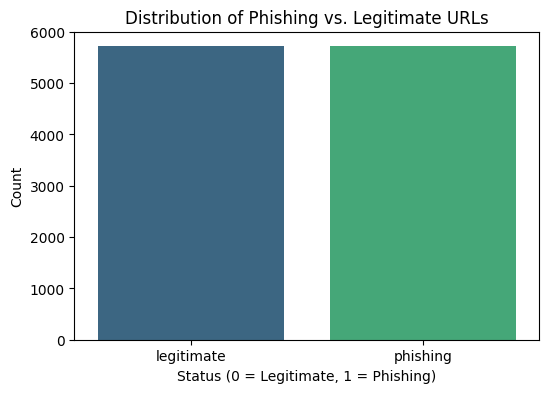

In [4]:
# Check the distribution of the target variable
print(df["status"].value_counts())

# Visualize the distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x=df["status"], palette="viridis")
plt.title("Distribution of Phishing vs. Legitimate URLs")
plt.xlabel("Status (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Count")
plt.show()


 Understanding Feature Types:-

In [5]:
# Check data types of each column
print(df.dtypes.value_counts())

# Show first few rows with data types
df.info()


int64      74
float64    13
object      2
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde            

Checking for Duplicates

In [6]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# If duplicates exist, remove them
if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")


Number of duplicate rows: 0
No duplicate rows found.


 Encoding the Target Column
 Your status column (which indicates phishing or legitimate URLs) is currently categorical (object type).

Legitimate URLs → 0

Phishing URLs → 1

We need to convert this into a numeric format for ML models.

In [7]:
# Encode the target variable
df['status'] = df['status'].map({'legitimate': 0, 'phishing': 1})

# Verify the encoding
print(df['status'].value_counts())
print("\nEncoding done!")


status
0    5715
1    5715
Name: count, dtype: int64

Encoding done!


Dropping Unnecessary Columns
Since the url column is a raw text feature, it won't contribute directly to our model. We should drop it.

In [8]:
# Drop the 'url' column
df = df.drop(columns=['url'])
print("Dropped 'url' column.")


Dropped 'url' column.


 Splitting Data into Train & Test Sets
Now, we need to split the dataset into:

Training Set (80%) → Used to train the model.

Test Set (20%) → Used to evaluate model performance.

In [9]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df.drop(columns=['status'])  # Features
y = df['status']  # Target variable

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print dataset shapes
print("Training Set Shape:", X_train.shape, y_train.shape)
print("Testing Set Shape:", X_test.shape, y_test.shape)


Training Set Shape: (9144, 87) (9144,)
Testing Set Shape: (2286, 87) (2286,)


Feature Scaling
Since our dataset contains numerical features with different ranges, we need to scale them to improve model performance.

In [10]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data (using the same scaler)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling done!")


Feature scaling done!


Choosing a Baseline Model
To start, we’ll train a simple Logistic Regression model as a baseline.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train the model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Model Accuracy: {accuracy:.4f}")


Baseline Model Accuracy: 0.9361


Evaluating the Model
We’ll analyze:

Confusion Matrix (TP, FP, FN, TN breakdown)

Precision, Recall, F1-Score (Useful for phishing detection)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[1074   69]
 [  77 1066]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      1143
           1       0.94      0.93      0.94      1143

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



 Save the Model for Future Use
Run this code to save your trained Logistic Regression model:




In [16]:
import joblib

# Save the trained model
joblib.dump(model, "phishing_model.pkl")

print("Model saved successfully!")


Model saved successfully!



Load & Test with New Data
To check how it works on new inputs, reload the model:

In [17]:
# Load the saved model
loaded_model = joblib.load("phishing_model.pkl")

# Predict using new sample data (replace with actual features)
sample_data = X_test.iloc[0:1]  # Example: first row of test data
prediction = loaded_model.predict(sample_data)

print("Predicted Class:", prediction[0])


Predicted Class: 1


C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
